# Portfolio Optimization using Black-Litterman

**Objective:** This notebook visualizes the final portfolio weights generated by our model. It takes the output from our data pipeline (`data/final/optimal_weights.csv`) and shows how we should allocate our capital across different S&P 500 sectors, combining the market's baseline with our XGBoost predictions.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Set a clean and professional style for the charts
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

In [5]:
# Load the final weights
weights_path = '../data/final/optimal_weights.csv'
df_weights = pd.read_csv(weights_path)

# Rename columns to make them easier to use
df_weights.columns = ['Sector_ETF', 'Optimal_Weight']

# Dictionary to map ETF tickers to their actual sector names
sector_names = {
    'XLK': 'Technology (XLK)',
    'XLC': 'Communication Services (XLC)',
    'XLY': 'Consumer Discretionary (XLY)',
    'XLF': 'Financials (XLF)',
    'XLV': 'Health Care (XLV)',
    'XLI': 'Industrials (XLI)',
    'XLE': 'Energy (XLE)',
    'XLP': 'Consumer Staples (XLP)',
    'XLB': 'Materials (XLB)',
    'XLRE': 'Real Estate (XLRE)',
    'XLU': 'Utilities (XLU)'
}

# Replace the tickers with the full names so anyone can understand the chart
df_weights['Sector_ETF'] = df_weights['Sector_ETF'].map(sector_names)

# Convert the percentage strings (like '28.73%') back into numbers for plotting
df_weights['Optimal_Weight'] = df_weights['Optimal_Weight'].astype(str).str.rstrip('%').astype(float) / 100

# Show the table
display(df_weights)

,Sector_ETF,Optimal_Weight
0,Technology (XLK),0.2873
1,Communication Services (XLC),0.2051
2,Consumer Discretionary (XLY),0.1673
3,Financials (XLF),0.0938
4,Industrials (XLI),0.0859
5,Health Care (XLV),0.0840
6,Materials (XLB),0.0401
7,Consumer Staples (XLP),0.0298
8,Real Estate (XLRE),0.0060
9,Utilities (XLU),0.0007


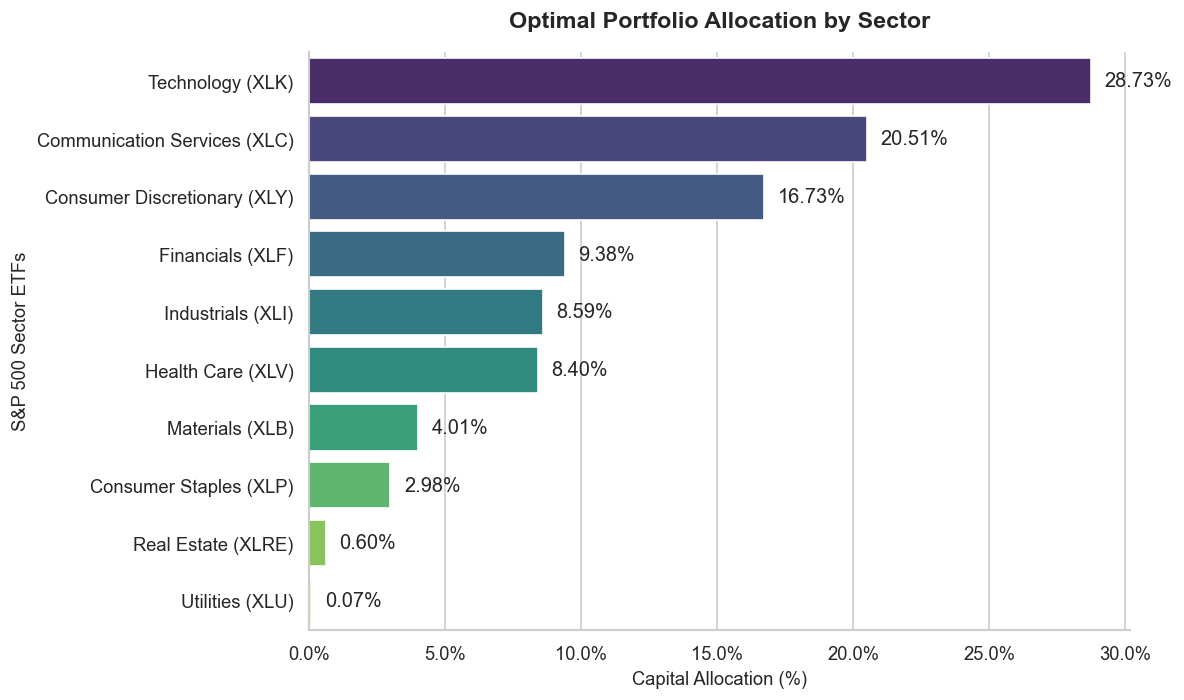

In [7]:
# Create the chart
plt.figure(figsize=(10, 6))

# Make a horizontal bar chart
ax = sns.barplot(
    data=df_weights, 
    x='Optimal_Weight', 
    y='Sector_ETF',
    hue='Sector_ETF', 
    palette='viridis',
    legend=False
)

# Show the x-axis values as percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add the exact percentage number at the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.005,      
        p.get_y() + p.get_height() / 2, 
        f'{width:.2%}',     
        va='center'
    )

# Add clear titles and labels
plt.title('Optimal Portfolio Allocation by Sector', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Capital Allocation (%)', fontsize=11)
plt.ylabel('S&P 500 Sector ETFs', fontsize=11)

# Remove the top and right borders to make it look cleaner
sns.despine()
plt.tight_layout()

# Save the image so we can use it in the README later
plt.savefig('../data/final/allocation_chart.png')
plt.show()